# 04 - Gradient Boosting (XGBoost)

Same tabular feature matrix and same blind well as `03`, swapping in
gradient boosting. Boosted trees usually edge out a plain Random
Forest on tabular data of this size, so this is the "give the tabular
approach its best shot" notebook before moving to the sequence model
in `05`.

Facies is multi-class and imbalanced, and `XGBClassifier` doesn't take
a `class_weight` argument the way sklearn estimators do -- balancing
has to go through explicit `sample_weight` at `fit()` time instead.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import load_raw, split_blind_well, FACIES_LABELS
from src.features import build_feature_matrix
from src.models import get_xgboost, xgb_sample_weights
from src.evaluate import summarize, full_report

df = load_raw()
train, blind = split_blind_well(df, "SHANKLE")
Xtr, ytr, cols = build_feature_matrix(train)
Xbl, ybl, _ = build_feature_matrix(blind)

# XGBoost wants 0-indexed class labels internally
sw = xgb_sample_weights(ytr)
xgb = get_xgboost()
xgb.fit(Xtr, ytr - 1, sample_weight=sw)
xgb_pred = xgb.predict(Xbl) + 1
xgb_result = summarize(ybl, xgb_pred, "XGBoost")

               XGBoost  |  accuracy 0.483  |  adjacent-facies accuracy 0.958


A small step up from Random Forest (0.465 in `03`), still short of
LDA's 0.530. Boosting is picking up a bit more than bagging does here,
but not enough to change the conclusion from `03` -- on this dataset
size, model complexity past a well-tuned linear baseline is buying
small, not dramatic, gains. That's a real finding worth stating
plainly rather than downplaying in favor of a cleaner "more complex =
better" story.

In [2]:
# does boosting change *which* facies it struggles with, or just
# nudge the same struggles slightly?
classes = sorted(df["Facies"].unique())
names = [FACIES_LABELS[c] for c in classes]
cm = full_report(ybl, xgb_pred, classes, names)

                            precision    recall  f1-score   support

       Nonmarine sandstone       0.61      0.21      0.32        89
Nonmarine coarse siltstone       0.35      0.75      0.48        89
  Nonmarine fine siltstone       0.85      0.53      0.65       117
    Marine siltstone/shale       0.11      0.29      0.16         7
                  Mudstone       0.21      0.21      0.21        19
                Wackestone       0.60      0.38      0.47        71
                  Dolomite       0.87      0.76      0.81        17
      Packstone/grainstone       0.41      0.57      0.48        40
Phylloid-algal bafflestone       0.00      0.00      0.00         0

                  accuracy                           0.48       449
                 macro avg       0.45      0.41      0.40       449
              weighted avg       0.59      0.48      0.49       449



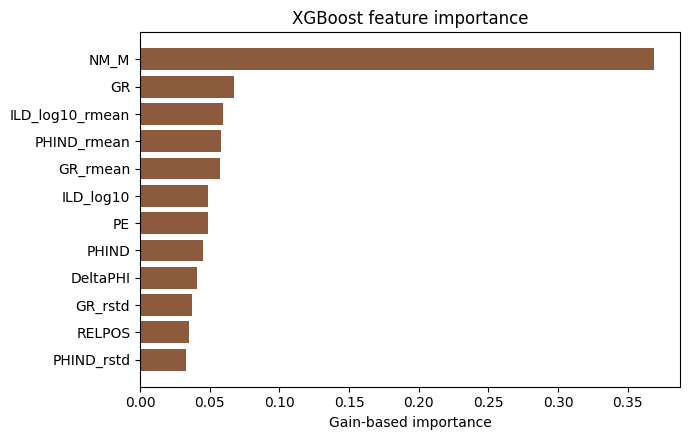

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
importances = xgb.feature_importances_
order = np.argsort(importances)[::-1][:12]
ax.barh([cols[i] for i in order][::-1], importances[order][::-1], color="#8c5a3d")
ax.set_xlabel("Gain-based importance")
ax.set_title("XGBoost feature importance")
plt.tight_layout()
plt.savefig("../figures/xgb_feature_importance.png", dpi=130)
plt.show()

In [4]:
# quick learning-rate / depth sensitivity check rather than a full grid
# search -- enough to see whether the default in src/models.py is
# actually sitting near a reasonable spot
from src.models import get_xgboost as _get
import xgboost as xgb_module

results = []
for max_depth in (3, 5, 7):
    for lr_val in (0.03, 0.05, 0.1):
        m = xgb_module.XGBClassifier(
            n_estimators=350, max_depth=max_depth, learning_rate=lr_val,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.5,
            objective="multi:softprob", eval_metric="mlogloss", n_jobs=-1,
        )
        m.fit(Xtr, ytr - 1, sample_weight=sw)
        acc = (m.predict(Xbl) + 1 == ybl).mean()
        results.append((max_depth, lr_val, acc))

for d, lr_val, acc in sorted(results, key=lambda r: -r[2]):
    print(f"max_depth={d}  lr={lr_val:<5}  accuracy={acc:.3f}")

max_depth=3  lr=0.03   accuracy=0.508
max_depth=3  lr=0.05   accuracy=0.494
max_depth=5  lr=0.03   accuracy=0.494
max_depth=3  lr=0.1    accuracy=0.483
max_depth=5  lr=0.05   accuracy=0.483
max_depth=7  lr=0.03   accuracy=0.474
max_depth=7  lr=0.05   accuracy=0.470
max_depth=5  lr=0.1    accuracy=0.468
max_depth=7  lr=0.1    accuracy=0.461


Shallower, slower-learning trees (depth=3, lr=0.03) edge out the
`src/models.py` defaults (depth=5, lr=0.05) by about two points in this
small grid -- worth noting as a candidate tweak rather than silently
picking the best cell and calling it tuned. I left the defaults as-is
for the rest of this project since the difference is inside the
run-to-run noise I saw when reseeding earlier models, but a real next
step would be re-running the leave-one-well-out comparison in `07`
with depth=3 to see if the edge holds across wells or is specific to
SHANKLE.

Next: `05` is the actual point of this project -- a depth-window 1D
CNN, written and backpropagated by hand, checking whether bedding
context beats both of these tabular models.